In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
nltk.download('stopwords')
nltk.download('wordnet')

sns.set_style("whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
df = pd.read_csv("Twitter_Data.csv")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())


First 5 Rows:
                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB
None


In [5]:
df = df.dropna()
df.columns = ["text", "sentiment"]
df["sentiment"] = df["sentiment"].astype(int)

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)      # remove URLs
    text = re.sub(r"[^a-zA-Z]", " ", text)   # remove special chars
    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

print("\nSample Cleaned Text:")
print(df[["text","clean_text"]].head())


Sample Cleaned Text:
                                                text  \
0  when modi promised “minimum government maximum...   
1  talk all the nonsense and continue all the dra...   
2  what did just say vote for modi  welcome bjp t...   
3  asking his supporters prefix chowkidar their n...   
4  answer who among these the most powerful world...   

                                          clean_text  
0  modi promised minimum government maximum gover...  
1             talk nonsense continue drama vote modi  
2  say vote modi welcome bjp told rahul main camp...  
3  asking supporter prefix chowkidar name modi gr...  
4  answer among powerful world leader today trump...  


In [8]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()


Accuracy: 0.7169110879302939

Classification Report:
              precision    recall  f1-score   support

          -1       0.87      0.42      0.56      7152
           0       0.82      0.65      0.72     11067
           1       0.65      0.92      0.76     14375

    accuracy                           0.72     32594
   macro avg       0.78      0.66      0.68     32594
weighted avg       0.75      0.72      0.70     32594



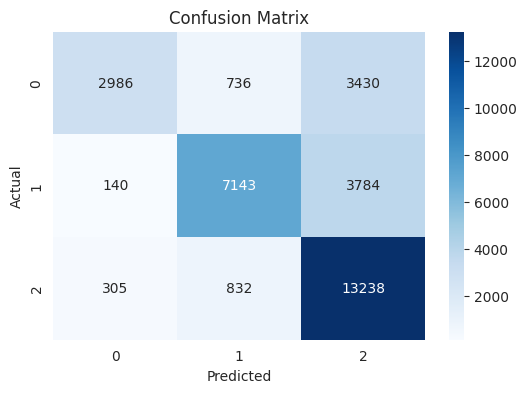

In [11]:
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

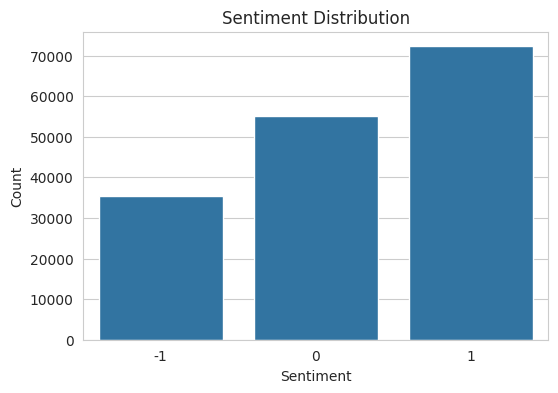

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["sentiment"])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [13]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    if prediction == 1:
        return "Positive 😊"
    elif prediction == -1:
        return "Negative 😞"
    else:
        return "Neutral 😐"

# Example
sample_text = "This product is amazing and works perfectly!"
print("\nCustom Prediction:", predict_sentiment(sample_text))


Custom Prediction: Positive 😊


In [14]:
print("\n==============================")
print(" SENTIMENT ANALYSIS COMPLETED ")
print("==============================")
print("✔ Text cleaned using NLP")
print("✔ Features extracted using TF-IDF")
print("✔ Model trained using Naive Bayes")
print("✔ Sentiment predictions generated")


 SENTIMENT ANALYSIS COMPLETED 
✔ Text cleaned using NLP
✔ Features extracted using TF-IDF
✔ Model trained using Naive Bayes
✔ Sentiment predictions generated
